# Decomposition

## Global Importation

In [1]:
# Shape modules 
from collections import defaultdict

# Computational modules 
%matplotlib inline
import xarray as xr
import glob
import os
import numpy as np
import netCDF4
from netCDF4 import Dataset
import pandas as pd
import re
from array import array
from pylab import *
from scipy.stats import ttest_ind

#import geopandas
#from eofs.xarray import Eof
#from eofs.multivariate.standard import MultivariateEof
import random
import cftime

# Plotting modules 
import matplotlib.pyplot as plt

#from mpl_toolkits.basemap import Basemap
import pandas.plotting
import matplotlib.ticker as ticker

#import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from cartopy.util import add_cyclic_point
from shapely.geometry import Polygon as ShapelyPolygon

"""
# Scikit-learn
from sklearn import linear_model
from sklearn.linear_model import LassoCV, LassoLarsCV, LassoLarsIC
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn import preprocessing
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
from scipy.optimize import dual_annealing
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
import scipy.stats as stats
from scipy.stats import ttest_ind
"""

# Dask
import dask
"""
from dask import delayed, compute
from dask.distributed import Client
"""

# tqdm + Remove warnings
from tqdm import tqdm 
import warnings
warnings.filterwarnings('ignore')

ERROR 1: PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed


## Global Inset

### Load Merged Data (Precipitation ESM-swl)

In [2]:
path_pr_files = '/home/users/alvin_ch/files/Multi-model/UKESM_ramp_up/Precip/'
filename = 'time_merged.nc'

ensemble = 'r1i1p1f1'
level_list = ["esm-swl3p0", "esm-swl4p0", "esm-swl5p0", "esm-swl6p0"]

level_run_model_1_pr_files = {}

for scenario in tqdm(level_list):
    level_run_model_1_pr_files[scenario] = xr.open_mfdataset(f'{path_pr_files}{scenario}_{ensemble}_{filename}', combine='by_coords', use_cftime=True)
    print(f'\n{scenario} Branch Off Start Date: ', level_run_model_1_pr_files[scenario]['time'].min().item())
    print(f'{scenario} Branch Off End Date: ', level_run_model_1_pr_files[scenario]['time'].max().item())

100%|████████████████████████████████████████████| 4/4 [00:03<00:00,  1.02it/s]


esm-swl3p0 Branch Off Start Date:  1992-01-16 00:00:00
esm-swl3p0 Branch Off End Date:  2411-12-16 00:00:00

esm-swl4p0 Branch Off Start Date:  2044-01-16 00:00:00
esm-swl4p0 Branch Off End Date:  2544-12-16 00:00:00

esm-swl5p0 Branch Off Start Date:  2082-01-16 00:00:00
esm-swl5p0 Branch Off End Date:  2394-12-16 00:00:00

esm-swl6p0 Branch Off Start Date:  2137-01-16 00:00:00
esm-swl6p0 Branch Off End Date:  2639-12-16 00:00:00


### Load Merged Data (Surface Humidity)

In [3]:
# These files were merged through cdo.
path_huss_files = '/home/users/alvin_ch/files/Multi-model/UKESM_ramp_up/Humidity/'
huss_filename = 'time_merge'

level_list = ["esm-swl3p0", "esm-swl4p0", "esm-swl5p0", "esm-swl6p0"]

level_run_model_1_huss_files = {}

for scenario in tqdm(level_list):
    level_run_model_1_huss_files[scenario] = xr.open_mfdataset(f'{path_huss_files}{huss_filename}_{scenario}_{ensemble}.nc', combine='by_coords', use_cftime=True)
    print(f'\n{scenario} Branch Off Start Date: ', level_run_model_1_huss_files[scenario]['time'].min().item())
    print(f'{scenario} Branch Off End Date: ', level_run_model_1_huss_files[scenario]['time'].max().item())

100%|████████████████████████████████████████████| 4/4 [00:00<00:00, 12.35it/s]


esm-swl3p0 Branch Off Start Date:  1992-01-16 00:00:00
esm-swl3p0 Branch Off End Date:  2411-12-16 00:00:00

esm-swl4p0 Branch Off Start Date:  2044-01-16 00:00:00
esm-swl4p0 Branch Off End Date:  2544-12-16 00:00:00

esm-swl5p0 Branch Off Start Date:  2082-01-16 00:00:00
esm-swl5p0 Branch Off End Date:  2394-12-16 00:00:00

esm-swl6p0 Branch Off Start Date:  2137-01-16 00:00:00
esm-swl6p0 Branch Off End Date:  2639-12-16 00:00:00


In [4]:
level_run_model_1_huss_files[level_list[0]]

<xarray.Dataset> Size: 558MB
Dimensions:    (time: 5040, bnds: 2, lon: 192, lat: 144)
Coordinates:
  * time       (time) object 40kB 1992-01-16 00:00:00 ... 2411-12-16 00:00:00
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 81kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    huss       (time, lat, lon) float32 557MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
Attributes: (12/41)
    CDI:                   Climate Data Interface version 2.5.0 (https://mpim...
    Conventions:           CF-1.7 CMIP-6.2
    source:                eUKESM1-1-ice-N96ORCA1 (2024)
    institution:           Met Office Hadley Centre, Fitzroy Road, Exeter, De...
    activity_id:           TerraFIRMA
    branch_method:         no parent
    ...                    ...
    variable_id:           huss
    variable_name:         huss
    variant_label:         r1i1p1f1
    license:               GCModelDev model data is licensed under the Open G...
    cmor_version:          3.8.0
    CDO:                   Climate Data Operators version 2.5.0 (https://mpim...

## Decomposition

### Implementation 1a

In [26]:
# Note that M_eff should not be interpreted as physical convective mass flux.
# It is an effective proxy which represents the processes linking surface moisture to precipitation.

def precipitation_decomposition(precip, humidity, baseline_precip=None, baseline_humidity=None):

    ### BASELINE CLIMATE - CLIMATOLOGY ###
    # If no baseline is provided, use the temporal mean.
    # Compute monthly climatology as the base.
    if baseline_precip is None:
        baseline_precip = precip.groupby("time.month").mean(dim="time")
        
    if baseline_humidity is None:
        baseline_humidity = humidity.groupby("time.month").mean(dim="time")

    # Baseline mass flux is the average of effective mass flux
    baseline_mass_flux = baseline_precip / baseline_humidity

    ### EFFECTIVE CONVECTIVE MASS-FLUX TERM ###
    # Mathematically denoted by M_eff = P / q
    effective_mass_flux = precip / humidity    

    ### DELTA VALUES ###
    # Calculate differences relative to baseline
    delta_precip = precip.groupby("time.month") - baseline_precip
    delta_humidity = humidity.groupby("time.month") - baseline_humidity
    delta_mass_flux = effective_mass_flux.groupby("time.month") - baseline_mass_flux

    # Thermodynamic term
    # ΔP_thermo = M0 Δq
    # i.e. Moisture changes with circulation held fixed.
    thermodynamic = baseline_mass_flux * delta_humidity.groupby("time.month")

    # Dynamic term
    # ΔP_dynamic = q0 ΔM
    # i.e. Circulation changes with moisture held fixed.
    dynamic = baseline_humidity * delta_mass_flux.groupby("time.month")

    # Nonlinear interaction term
    # ΔP_cross = ΔM Δq
    cross_term = delta_mass_flux * delta_humidity

    # Reconstruct total precipitation anomaly
    # This is used to calculate the residual.
    # The residual should be very close to zero.
    # This is because ΔP = ΔP_thermo + ΔP_dynamic + ΔP_cross
    reconstructed_delta_precip = thermodynamic + dynamic + cross_term
    residual = delta_precip - reconstructed_delta_precip

    # Return all components.
    decomposition = xr.Dataset({"effective_mass_flux": effective_mass_flux,
                                "delta_precip": delta_precip,
                                "delta_humidity": delta_humidity,
                                "delta_mass_flux": delta_mass_flux,
                                "thermodynamic": thermodynamic,
                                "dynamic": dynamic,
                                "cross_term": cross_term,
                                "reconstructed_delta_precip": reconstructed_delta_precip,
                                "residual": residual})
    return decomposition.compute()

## Preprocessing

### Convert Units

In [6]:
for scenario in level_list:
    level_run_model_1_pr_files[scenario] *= 86400
    level_run_model_1_huss_files[scenario] *= 100

## Test Section

### Load Test Data

In [7]:
# Load test data
# Test a small range of the dataset.
start_date = '1992-01-01'
end_date = '2100-01-01'

# Filter years and convert units.
ds_pr_test = level_run_model_1_pr_files[level_list[0]].sel(time=slice(start_date, end_date))

In [8]:
ds_pr_test['pr'].values[:1]

array([[[0.11249893, 0.11500826, 0.11228802, ..., 0.12441816,
         0.11801199, 0.11881551],
        [0.12168661, 0.12601513, 0.12393246, ..., 0.11745419,
         0.12198319, 0.12004969],
        [0.12907746, 0.14147909, 0.15142931, ..., 0.10291251,
         0.10736934, 0.11417382],
        ...,
        [1.3819821 , 1.3914633 , 1.417867  , ..., 1.3839196 ,
         1.3752662 , 1.3607339 ],
        [1.4516432 , 1.4649384 , 1.4652259 , ..., 1.4162722 ,
         1.4262053 , 1.4289289 ],
        [1.220157  , 1.2232783 , 1.2307601 , ..., 1.2200534 ,
         1.2169821 , 1.2171847 ]]], shape=(1, 144, 192), dtype=float32)

In [9]:
# Similarly for humidity.
# Units are converted into percentage.
ds_huss_test = level_run_model_1_huss_files[level_list[0]].sel(time=slice(start_date, end_date))

In [10]:
ds_huss_test['huss'].values[:1]

array([[[0.07765166, 0.07757828, 0.07757479, ..., 0.07767662,
         0.07760788, 0.07760007],
        [0.0805405 , 0.08048941, 0.08042578, ..., 0.08081858,
         0.08085683, 0.0808407 ],
        [0.08327639, 0.08344907, 0.08321402, ..., 0.08326562,
         0.08291478, 0.08311658],
        ...,
        [0.23126301, 0.23174874, 0.23242956, ..., 0.22790062,
         0.2286942 , 0.2299286 ],
        [0.22778717, 0.22813715, 0.22853948, ..., 0.2254662 ,
         0.22574349, 0.22676736],
        [0.23243481, 0.23241618, 0.23268636, ..., 0.23196808,
         0.23208156, 0.2323777 ]]], shape=(1, 144, 192), dtype=float32)

### Decomposition

In [11]:
# Perform test on our implementation.
test_decompose = precipitation_decomposition(ds_pr_test['pr'], ds_huss_test['huss'])

In [12]:
# Check dimensions
test_decompose

<xarray.Dataset> Size: 1GB
Dimensions:                     (time: 1296, lat: 144, lon: 192)
Coordinates:
  * time                        (time) object 10kB 1992-01-16 00:00:00 ... 20...
  * lat                         (lat) float64 1kB -89.38 -88.12 ... 88.12 89.38
  * lon                         (lon) float64 2kB 0.9375 2.812 ... 357.2 359.1
    height                      (time) float64 10kB 1.5 1.5 1.5 ... 1.5 1.5 1.5
    month                       (time) int64 10kB 1 2 3 4 5 6 ... 7 8 9 10 11 12
Data variables:
    effective_mass_flux         (time, lat, lon) float32 143MB dask.array<chunksize=(1, 36, 48), meta=np.ndarray>
    delta_precip                (time, lat, lon) float32 143MB dask.array<chunksize=(12, 36, 48), meta=np.ndarray>
    delta_humidity              (time, lat, lon) float32 143MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    delta_mass_flux             (time, lat, lon) float32 143MB dask.array<chunksize=(1, 36, 48), meta=np.ndarray>
    thermodynamic               (time, lat, lon) float32 143MB dask.array<chunksize=(1, 36, 48), meta=np.ndarray>
    dynamic                     (time, lat, lon) float32 143MB dask.array<chunksize=(1, 36, 48), meta=np.ndarray>
    cross_term                  (time, lat, lon) float32 143MB dask.array<chunksize=(1, 36, 48), meta=np.ndarray>
    reconstructed_delta_precip  (time, lat, lon) float32 143MB dask.array<chunksize=(1, 36, 48), meta=np.ndarray>
    residual                    (time, lat, lon) float32 143MB dask.array<chunksize=(1, 36, 48), meta=np.ndarray>

### Equation Term Values

In [13]:
print('Decomposed Results')

print('\nMin thermodynamic =', test_decompose['thermodynamic'].min().values)
print('Max thermodynamic =', test_decompose['thermodynamic'].max().values)

Decomposed Results

Min thermodynamic = -8.312225
Max thermodynamic = 10.0828905


In [14]:
print('Decomposed Results')

print('\nMin dynamic =', test_decompose['dynamic'].min().values)
print('Max dynamic =', test_decompose['dynamic'].max().values)

Decomposed Results

Min dynamic = -37.97284
Max dynamic = 255.37991


In [15]:
print('Decomposed Results')

print('\nMin Residual =', test_decompose['residual'].min().values)
print('Max Residual =', test_decompose['residual'].max().values)

Decomposed Results

Min Residual = -3.0517578e-05
Max Residual = 1.5258789e-05


## Application

In [27]:
"""
swl3p0_decompose = precipitation_decomposition(level_run_model_1_pr_files[level_list[0]]['pr'],
                                               level_run_model_1_huss_files[level_list[0]]['huss'])

swl4p0_decompose = precipitation_decomposition(level_run_model_1_pr_files[level_list[1]]['pr'],
                                               level_run_model_1_huss_files[level_list[1]]['huss'])

swl5p0_decompose = precipitation_decomposition(level_run_model_1_pr_files[level_list[2]]['pr'],
                                               level_run_model_1_huss_files[level_list[2]]['huss'])

swl6p0_decompose = precipitation_decomposition(level_run_model_1_pr_files[level_list[3]]['pr'],
                                               level_run_model_1_huss_files[level_list[3]]['huss'])
"""

In [37]:
# Store decomposed data.
# Compute function takes a long time.

path_files = '/home/users/alvin_ch/files/Multi-model/UKESM_ramp_up/Decomposition'
path_figure = '/home/users/alvin_ch/figures/Multi-model/UKESM_ramp_up/Decomposition'

save_names = ['swl3p0_decomposition_results', 'swl4p0_decomposition_results',
              'swl5p0_decomposition_results', 'swl6p0_decomposition_results']
decomp_results = [swl3p0_decompose, swl4p0_decompose, swl5p0_decompose, swl6p0_decompose]

for (file, results) in zip(save_names, decomp_results):
    ds = results
    ds.to_netcdf(f"{path_files}/{file}.nc")


'\nfor (file, results) in zip(save_names, decomp_results):\n    ds = results\n    ds.to_netcdf(f"{path_files}/{file}.nc")\n'

## Further Processing

In [38]:
decomposed_compiled_results = {scenario: {} for scenario in names}
names = ['3-degree warming', '4-degree warming', '5-degree warming', '6-degree warming']

for file, scenario in zip(tqdm(save_names), names):
    results_open = xr.open_dataset(f"{path_files}/{file}.nc")
    decomposed_compiled_results[scenario] = results_open

100%|████████████████████████████████████████████| 4/4 [00:02<00:00,  1.40it/s]


In [41]:
# Check coordinates and dimensions.
scenario = names[0]

ds = decompose_compiled_results[scenario]

print(ds.time[0].values)
print(ds.time[-1].values)

print(ds.time.dt.month.values[:20])
print(ds.month.values[:20])

1992-01-16 00:00:00
2411-12-16 00:00:00
[ 1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6  7  8]
[ 1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6  7  8]


### Standardise Coordinates

In [42]:
def standardise_coordinates(data):
    rename_dict = {}

    if 'lat' in data.coords:
        rename_dict['lat'] = 'latitude'

    if 'lon' in data.coords:
        rename_dict['lon'] = 'longitude'

    if rename_dict:
        data = data.rename(rename_dict)

    # Convert longitude from 0–360 to -180–180
    if data['longitude'].max() > 180:
        data = data.assign_coords(longitude=((data.longitude + 180) % 360) - 180)
        data = data.sortby('longitude')
    return data

### Compute Monthly Average Over Time

In [50]:
all_months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

anomaly_decomp_ds = {}
first_100_annual_mean = {}
last_100_annual_mean = {}

for scenario in names:
    decomp_ds = decompose_compiled_results[scenario]
    st_decomp_ds = standardise_coordinates(decomp_ds)
    
    # Extract only May-September - if needed
    all_ds = st_decomp_ds.where(st_decomp_ds.time.dt.month.isin(all_months), drop=True)

    # Get all available years.
    years = np.unique(all_ds.time.dt.year.values)
    first_100yrs = years[:100]
    last_100yrs = years[-100:]

    # Select first and last years
    first_100 = all_ds.where(all_ds.time.dt.year.isin(first_100yrs), drop=True)
    last_100 = all_ds.where(all_ds.time.dt.year.isin(last_100yrs), drop=True)

    # Average over years while keeping each month separate
    first_100_monthly = first_100.groupby('time.month').mean(dim='time')
    last_100_monthly = last_100.groupby('time.month').mean(dim='time')

    # Mean of last 100 years minus mean of first 100 years
    anomaly_decomp_ds[scenario] = last_100_monthly.mean('month') - first_100_monthly.mean('month')
    first_100_annual_mean[scenario] = first_100.groupby('time.year').mean('time')
    last_100_annual_mean[scenario] = last_100.groupby('time.year').mean('time')

In [51]:
# Check dataset dimensions and variables.
anomaly_decomp_ds[names[0]]

<xarray.Dataset> Size: 998kB
Dimensions:                     (latitude: 144, longitude: 192)
Coordinates:
  * latitude                    (latitude) float64 1kB -89.38 -88.12 ... 89.38
  * longitude                   (longitude) float64 2kB -179.1 -177.2 ... 179.1
Data variables:
    effective_mass_flux         (latitude, longitude) float32 111kB dask.array<chunksize=(36, 48), meta=np.ndarray>
    delta_precip                (latitude, longitude) float32 111kB dask.array<chunksize=(36, 48), meta=np.ndarray>
    delta_humidity              (latitude, longitude) float32 111kB dask.array<chunksize=(144, 192), meta=np.ndarray>
    delta_mass_flux             (latitude, longitude) float32 111kB dask.array<chunksize=(36, 48), meta=np.ndarray>
    thermodynamic               (latitude, longitude) float32 111kB dask.array<chunksize=(36, 48), meta=np.ndarray>
    dynamic                     (latitude, longitude) float32 111kB dask.array<chunksize=(36, 48), meta=np.ndarray>
    cross_term                  (latitude, longitude) float32 111kB dask.array<chunksize=(36, 48), meta=np.ndarray>
    reconstructed_delta_precip  (latitude, longitude) float32 111kB dask.array<chunksize=(36, 48), meta=np.ndarray>
    residual                    (latitude, longitude) float32 111kB dask.array<chunksize=(36, 48), meta=np.ndarray>

In [22]:
# Check data values whether they are the expected range.
print('Decomposition Preview Results (3-degree warming)')
print('\n')
print('Thermodynamic Mean =', anomaly_decomp_ds[names[0]]['thermodynamic'].mean().values)
print('Dynamic Mean =', anomaly_decomp_ds[names[0]]['dynamic'].mean().values)
print('Residual Mean =', anomaly_decomp_ds[names[0]]['residual'].mean().values)

Decomposition Preview Results (3-degree warming)


Thermodynamic Mean = 0.121811755
Dynamic Mean = -0.06021664
Residual Mean = 2.6221561e-11


In [23]:
print('Delta Precip Mean =', anomaly_decomp_ds[names[0]]['delta_precip'].mean().values)

Delta Precip Mean = 0.06306178


### Implementation 1b (Student t-Test)

In [45]:
def ttest_NO_bootstrap(data_scen, data_piCTL):
    n_scen = data_scen.shape[0]
    n_ctl = data_piCTL.shape[0]

    assert n_scen == n_ctl
    
    t_stat, p_value = ttest_ind(data_scen, data_piCTL, axis=0, equal_var=False)

    # Create an Xarray
    p_empirical_xr = xr.DataArray(p_value, dims=["latitude", 'longitude'],
                                  coords={"latitude": data_scen["latitude"],
                                          "longitude": data_scen["longitude"]},
                                  name="p_value")

    # Assign a name to your DataArray
    p_empirical_xr.name = "p_value"

    # Convert it to a Dataset (NetCDF requires a Dataset format)
    ds = p_empirical_xr.to_dataset()    
    return ds

### Compute Statistical Significance

In [ ]:
# Dictionary storing p-values for each level.
# This usually takes a while to run.
p_val_dict = {scenario: {} for scenario in names}
var_list = ['delta_precip', 'thermodynamic', 'dynamic', 'cross_term']
"""
for scenario in names:
    print('='*30)
    print(f'\nStarting {scenario}')
    
    for variable in var_list:
        print(f'  Starting {variable}')

        # Student-t
        data_first100 = first_100_annual_mean[scenario][variable]
        data_last100 = last_100_annual_mean[scenario][variable]
        %time p_val_dict[scenario][variable] = ttest_NO_bootstrap(data_first100, data_last100)
        
        print(f'  Finished {variable}\n')
"""

In [53]:
"""
# Check p-values
p_val_dict[names[0]]['delta_precip']
"""

<xarray.Dataset> Size: 113kB
Dimensions:    (latitude: 144, longitude: 192)
Coordinates:
  * latitude   (latitude) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * longitude  (longitude) float64 2kB -179.1 -177.2 -175.3 ... 177.2 179.1
Data variables:
    p_value    (latitude, longitude) float32 111kB 2.485e-12 2.56e-09 ... 0.1056

In [56]:
def save_p_values(p_val_dict, names, path_files):

    for scenario in names:
        scenario_path = os.path.join(path_files, scenario)
        os.makedirs(scenario_path, exist_ok=True)

        for variable, ds in p_val_dict[scenario].items():
            filename = f'{scenario}_{variable}_pvalues.nc'
            filepath = os.path.join(scenario_path, filename)

            ds.to_netcdf(filepath)

In [57]:
save_p_values(p_val_dict, names, path_files)

In [63]:
# Check data on saved files.
ds = xr.open_dataset(f'{path_files}/{scenario}/{scenario}_{variable}_pvalues.nc')
ds['p_value'].values[:1]

array([[2.03600823e-04, 3.68897454e-04, 1.90084917e-04, 9.74569484e-05,
        1.77787806e-04, 9.55676805e-05, 8.71497105e-05, 9.39860329e-05,
        4.91554492e-05, 8.37647240e-05, 3.37237434e-05, 1.43818586e-04,
        5.92597498e-05, 1.22221740e-04, 1.28145111e-04, 1.33170135e-04,
        6.29362767e-05, 5.02129260e-04, 1.50424443e-04, 4.96916356e-04,
        4.60153795e-04, 4.96853550e-04, 5.32704173e-04, 2.11007055e-03,
        2.14567711e-03, 5.82020031e-03, 8.39916058e-03, 1.09801777e-02,
        1.33590335e-02, 1.84693858e-02, 2.27828957e-02, 2.53445469e-02,
        3.67040224e-02, 4.40200828e-02, 5.66520914e-02, 7.11588636e-02,
        8.40246156e-02, 1.14444152e-01, 1.33941054e-01, 1.47577226e-01,
        1.64066210e-01, 1.68308899e-01, 2.01718241e-01, 2.12100714e-01,
        2.13047832e-01, 2.36536369e-01, 2.56364703e-01, 2.48418361e-01,
        2.75980115e-01, 2.98655152e-01, 3.04223776e-01, 3.03146303e-01,
        2.80546099e-01, 3.02924693e-01, 2.85195172e-01, 2.688645

## Results Review

### Implementation 2a (Plot)

In [24]:
# The input for decompose_data is the dataset corresponding to the senario input.
# Data input is the last 100 and first 100 years anomaly.
def decompose_results_map(decompose_data, scenario, lonmin, lonmax, latmin, latmax,
                          vmin_clim, vmax_clim, levels_clim,
                          vmin_decomp, vmax_decomp, levels_decomp,
                          vmin_cross, vmax_cross, levels_cross,
                          save, filename):
    
    # Set up figure.
    fig, axes = plt.subplots(2, 2, figsize=(20, 10), 
                             subplot_kw={'projection': ccrs.PlateCarree()}, constrained_layout=True)

    fig.subplots_adjust(wspace=0.05, hspace=1.20)
    
    axes = axes.flatten()

    # Define variables of interest.
    # Cross term is deliberately excluded because it is very small.
    plot_variables = ['delta_precip', 'cross_term', 'thermodynamic', 'dynamic', ]

    # Title for the three columns.
    column_titles = ['Δ Precipitation', 'Cross Term (Nonlinear Interaction)',
                     'Thermodynamic Contribution', 'Dynamic Contribution']

    # Plot for each four decomposition components.
    for i, (variable, column_title) in enumerate(zip(plot_variables, column_titles)):

        data = decompose_data[variable]

        if 'lon' in data.coords:
            data = data.rename({'lon': 'longitude'})
        if 'lat' in data.coords:
            data = data.rename({'lat': 'latitude'})
    
        lon_orig = data['longitude'].values
        lat = data['latitude'].values

        data_cyclic, lon_cyclic = add_cyclic_point(data.values, coord=lon_orig, axis=-1)
        lon2d, lat2d = np.meshgrid(lon_cyclic, lat)
            
        # Define different colour palettes for each term.
        if variable == 'delta_precip':
            vmin = vmin_clim
            vmax = vmax_clim
            levels = levels_clim
            cmap = 'Blues'

        # Define different colour palettes for each term.
        elif variable == 'cross_term':
            vmin = vmin_cross
            vmax = vmax_cross
            levels = levels_cross
            cmap = 'BrBG'

        # Thermodynamic and dyanmic maps should use the same colour palette.
        # To directly compare their roles to the precipitation pattern.
        else:
            vmin = vmin_decomp
            vmax = vmax_decomp
            levels = levels_decomp
            cmap = 'RdBu'

        # Filled contours
        contour = axes[i].contourf(lon2d, lat2d, data_cyclic, levels=levels, cmap=cmap, extend='both',
                                      transform=ccrs.PlateCarree())
        mm = axes[i].pcolormesh(lon2d, lat2d, data_cyclic, vmin=vmin, vmax=vmax,
                                   transform=ccrs.PlateCarree(), cmap=cmap)

        # Significance stippling
        if p_values[scenario]['p_value'] is not None:
            pvals = p_values[scenario]['p_value'].mean('longitude')
            sig_mask = pvals.values <= 0.05
            hatch_mask = np.where(sig_mask, 1, np.nan)
            axes[i].pcolor(lat2d, pressure2d, hatch_mask, hatch='..', alpha=0.0, zorder=3)
        
        # Formatting
        axes[i].set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
        axes[i].coastlines()
        axes[i].gridlines(draw_labels=True)
        axes[i].set_title(column_title, fontsize=16)

    # Colourbars
    # Delta Precip
    cbar_precip = fig.colorbar(axes[0].collections[0], ax=axes[0], orientation='horizontal',
                               fraction=0.08, pad=0.03)
    cbar_precip.set_label('ΔP (mm/day)', fontsize=14)

    # Cross Term
    cbar_decomp = fig.colorbar(axes[1].collections[0], ax=axes[1], orientation='horizontal',
                               fraction=0.08, pad=0.03)
    cbar_decomp.set_label('Nonlinear Interaction (mm/day)', fontsize=14)

    # Colourbar shared by thermodynamic and dynamic terms
    cbar_decomp = fig.colorbar(axes[3].collections[0], ax=axes[2:], orientation='horizontal',
                               fraction=0.08, pad=0.03)
    cbar_decomp.set_label('Precipitation Contribution (mm/day)', fontsize=14)
    
    fig.suptitle(f'Precipitation Decomposition Under Net-Zero Stabilisation ({scenario})', fontsize=20)

    if save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)
    plt.show()

### Resultant Figure

In [25]:
vmin_clim, vmax_clim = 0, 1
levels_clim = np.arange(vmin_clim, vmax_clim, 0.1)

vmin_decomp, vmax_decomp = -0.35, 0.35
levels_decomp = np.arange(vmin_decomp, vmax_decomp, 0.01)

vmin_cross, vmax_cross = -0.05, 0.05
levels_cross = np.arange(vmin_cross, vmax_cross, 0.001)

lonmin, lonmax = -180, 180
latmin, latmax = -90, 90

save = True
save_path = '/home/users/alvin_ch/files/Multi-model/UKESM_ramp_up'
filename_3_deg = f'{save_path}/decomposition_net-zero_maps_3-deg.png'

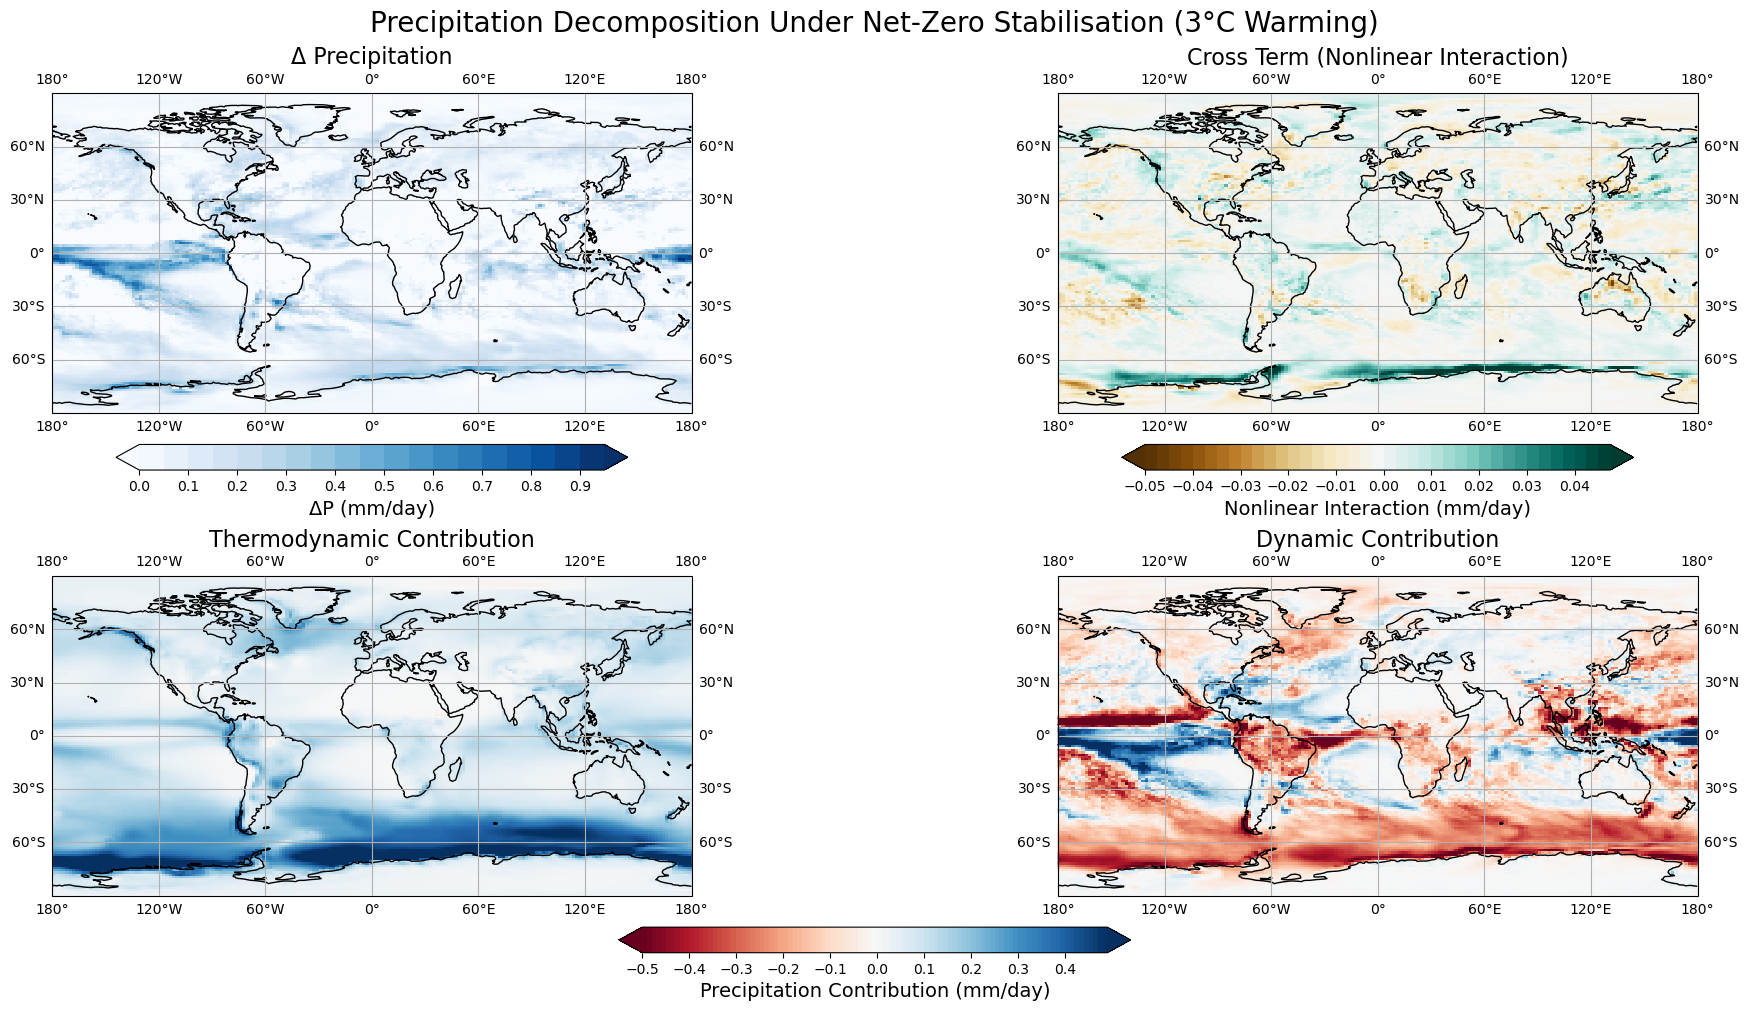

In [40]:
# This usually takes a while to load since it is handling very large datasets...
decomp_3_deg = anomaly_decomp_ds[names[0]]
scenario_3_deg = '3°C Warming'

decompose_results_map(decomp_3_deg, scenario_3_deg, lonmin, lonmax, latmin, latmax,
                      vmin_clim, vmax_clim, levels_clim,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      vmin_cross, vmax_cross, levels_cross,
                      save, filename_3_deg)

In [ ]:
filename_4_deg = f'{save_path}/decomposition_net-zero_maps_4-deg.png'
decomp_4_deg = anomaly_decomp_ds[names[1]]
scenario_4_deg = '4°C Warming'

decompose_results_map(decomp_4_deg, scenario_4_deg, lonmin, lonmax, latmin, latmax,
                      vmin_clim, vmax_clim, levels_clim,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      vmin_cross, vmax_cross, levels_cross,
                      save, filename_4_deg)

In [ ]:
# To add-on later...

# Maybe add stippling 
# Compare data in first and last 100 years using student t-test